# VGG 16 with Transfer Learning

### Importing Libraries

In [83]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [102]:
import tensorflow as tf
from keras.layers import Input, Lambda, Dense, Flatten, GlobalAveragePooling2D, Dropout
from keras.models import Model
from tensorflow.keras import models, layers
from keras.applications.vgg16 import VGG16
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import preprocess_input
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Load Dataset

In [85]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original')

Found 2527 files belonging to 6 classes.


In [86]:
dataset_name = dataset
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [87]:
BATCH_SIZE = 32
IMAGE_SIZE = [224,224]
SEED = 123
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

In [88]:
# Load the entire dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset-original',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 2527 files belonging to 6 classes.


In [89]:
# Calculate splits based on NUMBER OF BATCHES (not images)
total_batches = len(full_ds)
num_test_batches = int(total_batches * TEST_SPLIT)
num_val_batches = int(total_batches * VALIDATION_SPLIT)
num_train_batches = total_batches - num_test_batches - num_val_batches

print(f'Total Batches: {total_batches}')
print(f'Batches allocated for Training: {num_train_batches}')
print(f'Batches allocated for Validation: {num_val_batches}')
print(f'Batches allocated for Testing: {num_test_batches}')

# Approximate total images (last batch might be smaller)
approx_total_images = total_batches * BATCH_SIZE
print(f'Approximate Total Images: {approx_total_images}')

# Create datasets using batch-based slicing
train_ds = full_ds.take(num_train_batches)
val_ds = full_ds.skip(num_train_batches).take(num_val_batches)
test_ds = full_ds.skip(num_train_batches + num_val_batches)

def count_images_in_dataset(dataset):
    count = 0
    for batch in dataset:
        count += batch[0].shape[0]  # batch[0] is images, shape[0] is batch size
    return count

print(f'Actual images in train_ds: {count_images_in_dataset(train_ds)}')
print(f'Actual images in val_ds: {count_images_in_dataset(val_ds)}')
print(f'Actual images in test_ds: {count_images_in_dataset(test_ds)}')

Total Batches: 79
Batches allocated for Training: 57
Batches allocated for Validation: 15
Batches allocated for Testing: 7
Approximate Total Images: 2528
Actual images in train_ds: 1824
Actual images in val_ds: 480
Actual images in test_ds: 223


In [90]:
# Use preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [91]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

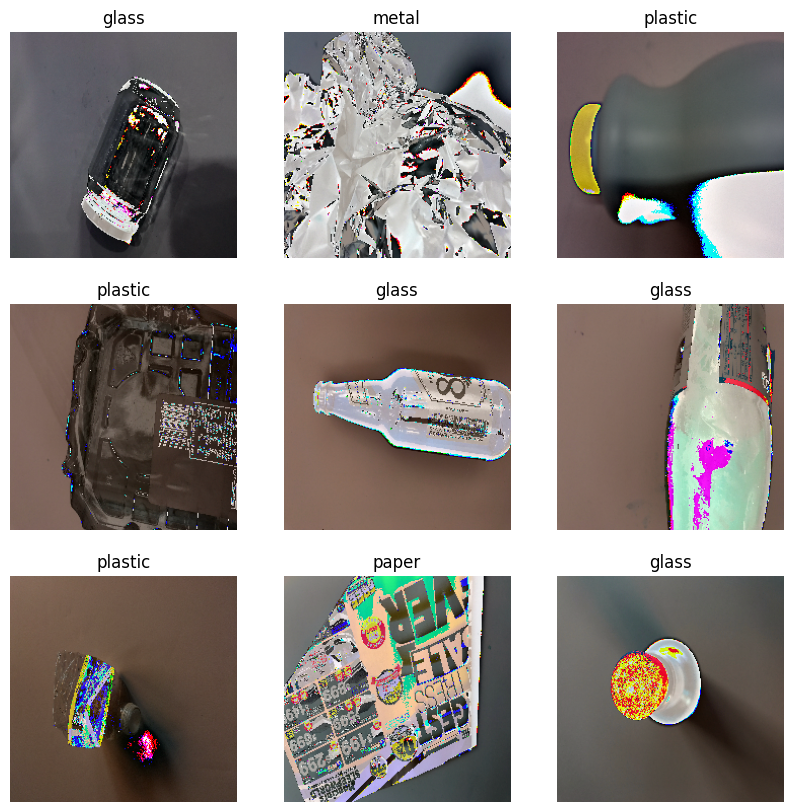

In [92]:
# Display first 9 images

plt.figure(figsize=(10, 10))
for x, y in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(x[i].numpy().astype("uint8"))
    plt.title(class_names[y[i]])
    plt.axis("off")

### Data Augmentation

In [93]:
# Create data generator for data augmentation in training set
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [94]:
# Create training and validation data generators
train_generator = train_datagen.flow_from_directory(
    'dataset-original',
    target_size=(224, 224),  # Resize images to this size
    batch_size=32,
    class_mode='sparse',  # Produce integer labels
    subset='training',  # Set as training data
    seed=123  # for reproducibility
)

val_generator = train_datagen.flow_from_directory(
    'dataset-original',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='validation',  # Set as validation data
    seed=123
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [95]:
class_names = train_generator.class_indices  # Returns a dictionary of class names and indices
num_classes = len(train_generator.class_indices)  # Number of classes

print(class_names)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [96]:
# Check the class mappings
print("Class indices:", train_generator.class_indices)
print("Number of classes:", train_generator.num_classes)

# Preview a batch of labels
images, labels = next(train_generator)
print("Labels shape:", labels.shape)
print("First few labels (should be integers):", labels[:10])
print("Labels dtype:", labels.dtype)

Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Number of classes: 6
Labels shape: (32,)
First few labels (should be integers): [1. 2. 2. 2. 3. 5. 3. 2. 1. 2.]
Labels dtype: float32


### Feature Extraction

### Model

In [97]:
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [98]:
for layer in vgg.layers:
  layer.trainable = False # freeze

In [103]:
# x = Flatten()(vgg.output)
x = GlobalAveragePooling2D()(vgg.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
prediction = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs=vgg.input, outputs=prediction)

In [104]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape                  ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)         │ (None, 224, 224, 3)           │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block1_conv1 (Conv2D)              │ (None, 224, 224, 64)          │       1,792 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block1_conv2 (Conv2D)              │ (None, 224, 224, 64)          │      36,928 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block1_pool (MaxPooling2D)         │ (None, 112, 112, 64)          │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block2_conv1 (Conv2D)              │ (None, 112, 112, 128)         │      73,856 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block2_conv2 (Conv2D)              │ (None, 112, 112, 128)         │     147,584 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block2_pool (MaxPooling2D)         │ (None, 56, 56, 128)           │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block3_conv1 (Conv2D)              │ (None, 56, 56, 256)           │     295,168 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block3_conv2 (Conv2D)              │ (None, 56, 56, 256)           │     590,080 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block3_conv3 (Conv2D)              │ (None, 56, 56, 256)           │     590,080 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block3_pool (MaxPooling2D)         │ (None, 28, 28, 256)           │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block4_conv1 (Conv2D)              │ (None, 28, 28, 512)           │   1,180,160 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block4_conv2 (Conv2D)              │ (None, 28, 28, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block4_conv3 (Conv2D)              │ (None, 28, 28, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block4_pool (MaxPooling2D)         │ (None, 14, 14, 512)           │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block5_conv1 (Conv2D)              │ (None, 14, 14, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block5_conv2 (Conv2D)              │ (None, 14, 14, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block5_conv3 (Conv2D)              │ (None, 14, 14, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block5_pool (MaxPooling2D)         │ (None, 7, 7, 512)             │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ global_average_pooling2d_1         │ (None, 512)                   │           0 │
│ (GlobalAveragePooling2D)           │                               │             │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dense_5 (Dense)                    │ (None, 256)                   │     131,328 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dropout (Dropout)                  │ (None, 256)                   │           0 │
├────

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [105]:
# Compile the model
model.compile(optimizer=Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10


C:\Users\Hasya Hazizi\anaconda3\envs\FYP\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 316s 5s/step - accuracy: 0.2298 - loss: 4.5895 - val_accuracy: 0.4592 - val_loss: 1.8377
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 305s 4s/step - accuracy: 0.4051 - loss: 2.7936 - val_accuracy: 0.5567 - val_loss: 1.4199
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 307s 5s/step - accuracy: 0.5053 - loss: 1.9770 - val_accuracy: 0.5984 - val_loss: 1.2385
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 317s 5s/step - accuracy: 0.5642 - loss: 1.5809 - val_accuracy: 0.6163 - val_loss: 1.1100
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 314s 5s/step - accuracy: 0.6142 - loss: 1.2801 - val_accuracy: 0.6183 - val_loss: 1.1110
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 321s 5s/step - accuracy: 0.6392 - loss: 1.1747 - val_accuracy: 0.6322 - val_loss: 0.9999
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 321s 5s/step - accuracy: 0.6561 - loss: 1.0770 - val_accuracy: 0.6680 - val_loss: 0.9455
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 316s 5s/step - accuracy: 0.6863 - loss: 0.9720 - val_accuracy: 0.6799 - val_loss: 0.

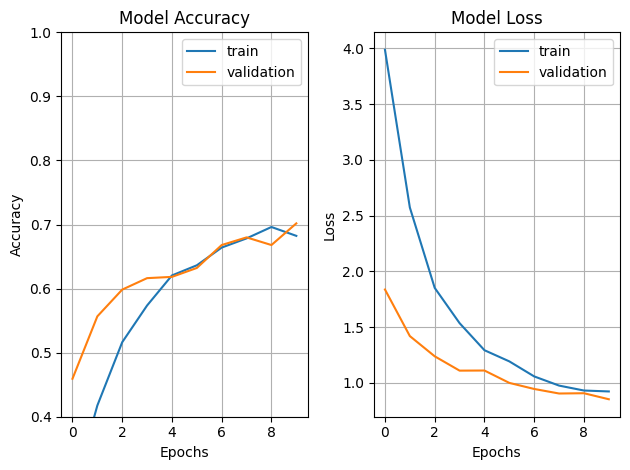

In [106]:
fig1 = plt.gcf()
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])

plt.tight_layout()
plt.show()

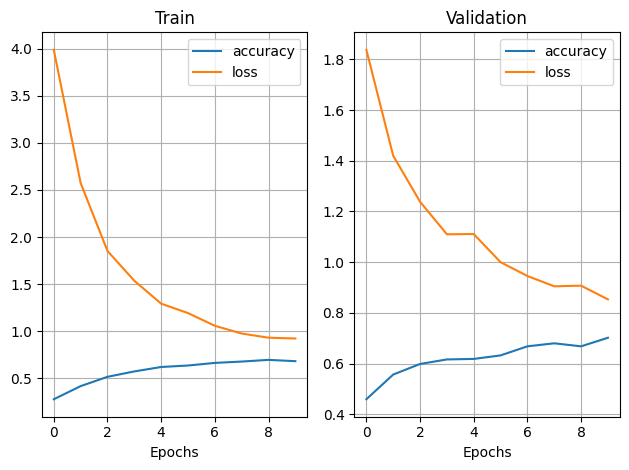

In [107]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.grid()
plt.title('Train')
plt.xlabel('Epochs')
plt.legend(['accuracy', 'loss'])

plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Validation')
plt.xlabel('Epochs')
plt.legend(['accuracy', 'loss'])

plt.tight_layout()
plt.show()

### Making predictions using validation dataset

In [108]:
print(f'Test images (batches): {test_ds.cardinality().numpy()}')

Test images (batches): 7


In [109]:
# Make predictions on the test dataset (test_ds)
y_pred_probs = model.predict(test_ds)

# For multi-class classification, convert probabilities to class predictions
y_pred = np.argmax(y_pred_probs, axis=1)  # Get the predicted classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step  


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Model expects class order: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


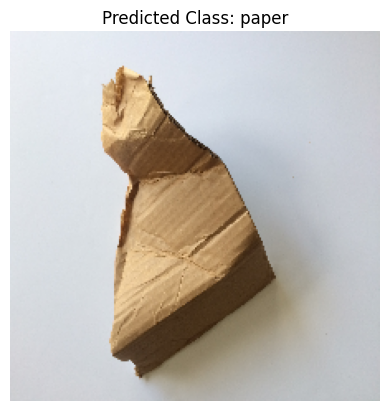

In [117]:
# Constants
IMAGE_PATH = 'dataset-original/cardboard/cardboard145.jpg'
IMAGE_SIZE = (224, 224)  # VGG16 requires 224x224

# Load the image
img = image.load_img(IMAGE_PATH, target_size=IMAGE_SIZE)
img_array = image.img_to_array(img)

# Preprocess the image PROPERLY for VGG16
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = preprocess_input(img_array)  # VGG16 specific preprocessing (DO NOT divide by 255!)

# Make predictions
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions, axis=1)

# Verify class order matches training
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
print("Model expects class order:", train_generator.class_indices)  # Add this line

# Display results
plt.imshow(img)  # Show original image (not preprocessed array)
plt.title(f'Predicted Class: {class_names[predicted_class[0]]}')
plt.axis('off')
plt.show()

### Measurement matrix

In [111]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [112]:
# Extract true labels from the validation dataset
y_true = []

# Iterate over the validation dataset to retrieve true labels
for images, labels in test_ds:
    # Since labels are not one-hot encoded, we can directly extend y_true with labels
    y_true.extend(labels.numpy())  # No need for np.argmax

# Convert y_true to a NumPy array and flatten if needed
y_true = np.array(y_true).flatten()  # Flatten if labels are in (batch_size, 1) shape

In [114]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred)
error_rate = 1 - accuracy

# Print the metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Error Rate: {error_rate:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')

Accuracy: 0.2242
Precision: 0.2249
Recall: 0.2242
F1 Score: 0.2227
Error Rate: 0.7758
Confusion Matrix:
[[ 6  9  6  6  5  2]
 [ 9 11  9 13 12  1]
 [ 3  7  4 12  5  2]
 [ 6  8 12 20 11  0]
 [ 6  6  2 11  7  2]
 [ 1  1  0  4  2  2]]
